## Task 5: Per-Tensor and Per-Channel Quantization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

conv_weights = np.random.randn(
    8, 3, 3, 3
).astype(np.float32)

# Create channel range imbalance
conv_weights[0] *= 0.1
conv_weights[1] *= 0.5
conv_weights[6] *= 5.0
conv_weights[7] *= 10.0

print("Tensor Shape:", conv_weights.shape)

Tensor Shape: (8, 3, 3, 3)


In [3]:
def compute_mae(original, reconstructed):
    return np.mean(
        np.abs(original - reconstructed)
    )

def compute_mse(original, reconstructed):
    return np.mean(
        (original - reconstructed) ** 2
    )

def compute_max_error(original, reconstructed):
    return np.max(
        np.abs(original - reconstructed)
    )

Per-Tensor Quantization

In [4]:
def per_tensor_quantize(tensor):

    q_min = -127
    q_max = 127

    max_abs = np.max(
        np.abs(tensor)
    )

    scale = max_abs / q_max

    q = np.round(
        tensor / scale
    )

    q = np.clip(
        q,
        q_min,
        q_max
    )

    q = q.astype(np.int8)

    dq = q.astype(np.float32) * scale

    return q, dq, scale

Per-Channel Quantization

In [5]:
def per_channel_quantize(tensor):

    q_min = -127
    q_max = 127

    q = np.zeros_like(
        tensor,
        dtype=np.int8
    )

    dq = np.zeros_like(
        tensor,
        dtype=np.float32
    )

    scales = []

    for c in range(
        tensor.shape[0]
    ):

        channel = tensor[c]

        max_abs = np.max(
            np.abs(channel)
        )

        scale = max_abs / q_max

        scales.append(scale)

        q_channel = np.round(
            channel / scale
        )

        q_channel = np.clip(
            q_channel,
            q_min,
            q_max
        )

        q[c] = q_channel.astype(np.int8)

        dq[c] = (
            q[c].astype(np.float32)
            * scale
        )

    return (
        q,
        dq,
        np.array(scales)
    )

Run Both Quantization Methods

In [6]:
q_tensor, dq_tensor, tensor_scale = (
    per_tensor_quantize(
        conv_weights
    )
)

q_channel, dq_channel, channel_scales = (
    per_channel_quantize(
        conv_weights
    )
)

print("Per-Tensor Scale:")
print(tensor_scale)

print("\nPer-Channel Scales:")
print(channel_scales)

Per-Tensor Scale:
0.30336466

Per-Channel Scales:
[0.00150652 0.00771524 0.02062791 0.01485186 0.01939561 0.01469114
 0.10709327 0.30336466]


Comparison Table

In [7]:
rows = []

for c in range(8):

    original = conv_weights[c]

    tensor_mae = compute_mae(
        original,
        dq_tensor[c]
    )

    channel_mae = compute_mae(
        original,
        dq_channel[c]
    )

    channel_min = np.min(original)
    channel_max = np.max(original)

    better = (
        "Per-Channel"
        if channel_mae < tensor_mae
        else "Per-Tensor"
    )

    rows.append([
        c,
        f"({channel_min:.3f}, {channel_max:.3f})",
        tensor_scale,
        tensor_mae,
        channel_scales[c],
        channel_mae,
        better
    ])

comparison_df = pd.DataFrame(
    rows,
    columns=[
        "Channel",
        "Range (min,max)",
        "Per-Tensor Scale",
        "Per-Tensor MAE",
        "Per-Ch Scale",
        "Per-Ch MAE",
        "Better"
    ]
)

comparison_df

,Channel,"Range (min,max)",Per-Tensor Scale,Per-Tensor MAE,Per-Ch Scale,Per-Ch MAE,Better
0,0,"(-0.191, 0.158)",0.303365,0.071464,0.001507,0.000326,Per-Channel
1,1,"(-0.980, 0.926)",0.303365,0.072564,0.007715,0.001661,Per-Channel
2,2,"(-2.620, 1.565)",0.303365,0.072175,0.020628,0.005373,Per-Channel
3,3,"(-1.464, 1.886)",0.303365,0.071594,0.014852,0.003731,Per-Channel
4,4,"(-1.919, 2.463)",0.303365,0.070571,0.019396,0.003995,Per-Channel
5,5,"(-1.607, 1.866)",0.303365,0.068939,0.014691,0.003901,Per-Channel
6,6,"(-5.354, 13.601)",0.303365,0.077800,0.107093,0.027714,Per-Channel
7,7,"(-15.148, 38.527)",0.303365,0.064038,0.303365,0.064038,Per-Tensor


Add Average Row

In [8]:
avg_row = pd.DataFrame(
    [[
        "Average",
        "",
        comparison_df["Per-Tensor Scale"].mean(),
        comparison_df["Per-Tensor MAE"].mean(),
        comparison_df["Per-Ch Scale"].mean(),
        comparison_df["Per-Ch MAE"].mean(),
        ""
    ]],
    columns=comparison_df.columns
)

comparison_df_final = pd.concat(
    [comparison_df, avg_row],
    ignore_index=True
)

comparison_df_final

,Channel,"Range (min,max)",Per-Tensor Scale,Per-Tensor MAE,Per-Ch Scale,Per-Ch MAE,Better
0,0,"(-0.191, 0.158)",0.303365,0.071464,0.001507,0.000326,Per-Channel
1,1,"(-0.980, 0.926)",0.303365,0.072564,0.007715,0.001661,Per-Channel
2,2,"(-2.620, 1.565)",0.303365,0.072175,0.020628,0.005373,Per-Channel
3,3,"(-1.464, 1.886)",0.303365,0.071594,0.014852,0.003731,Per-Channel
4,4,"(-1.919, 2.463)",0.303365,0.070571,0.019396,0.003995,Per-Channel
5,5,"(-1.607, 1.866)",0.303365,0.068939,0.014691,0.003901,Per-Channel
6,6,"(-5.354, 13.601)",0.303365,0.077800,0.107093,0.027714,Per-Channel
7,7,"(-15.148, 38.527)",0.303365,0.064038,0.303365,0.064038,Per-Tensor
8,Average,,0.303365,0.071143,0.061156,0.013842,


Visualize MAE per Channel

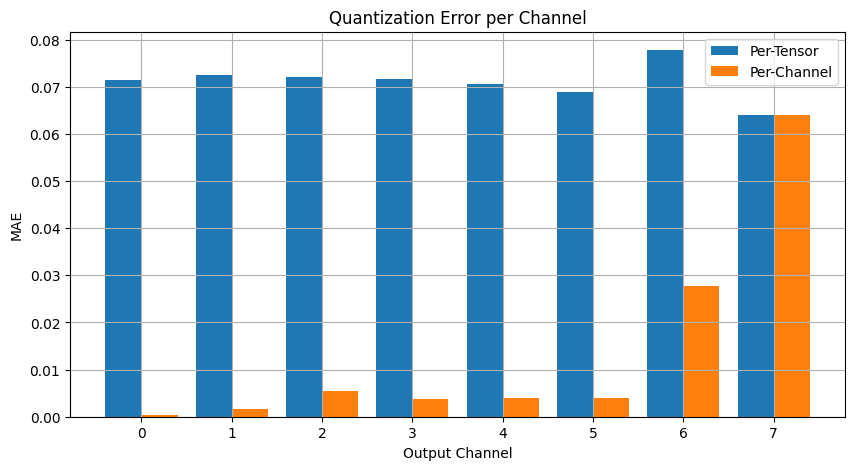

In [9]:
plt.figure(figsize=(10,5))

channels = np.arange(8)

plt.bar(
    channels - 0.2,
    comparison_df["Per-Tensor MAE"],
    width=0.4,
    label="Per-Tensor"
)

plt.bar(
    channels + 0.2,
    comparison_df["Per-Ch MAE"],
    width=0.4,
    label="Per-Channel"
)

plt.xlabel("Output Channel")
plt.ylabel("MAE")
plt.title(
    "Quantization Error per Channel"
)

plt.legend()
plt.grid(True)

plt.show()

Visualize Channel Scales

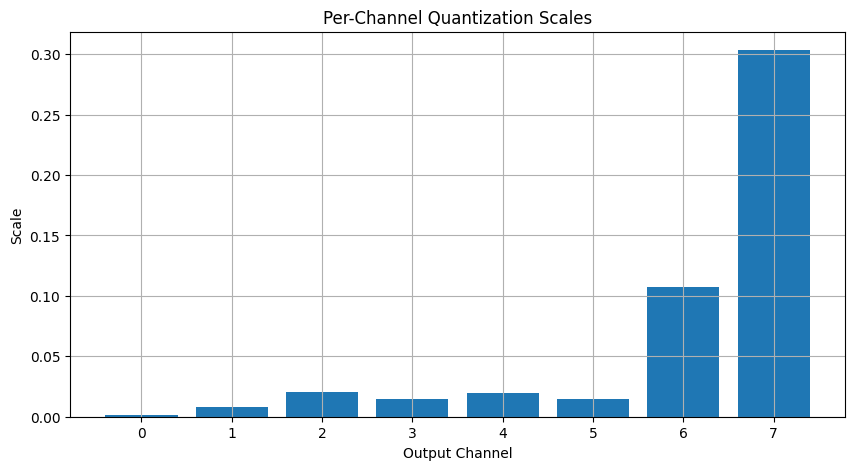

In [10]:
plt.figure(figsize=(10,5))

plt.bar(
    np.arange(8),
    channel_scales
)

plt.xlabel("Output Channel")
plt.ylabel("Scale")

plt.title(
    "Per-Channel Quantization Scales"
)

plt.grid(True)

plt.show()

Additional Metrics (Optional)

In [11]:
extra_rows = []

for c in range(8):

    mse_tensor = compute_mse(
        conv_weights[c],
        dq_tensor[c]
    )

    mse_channel = compute_mse(
        conv_weights[c],
        dq_channel[c]
    )

    max_tensor = compute_max_error(
        conv_weights[c],
        dq_tensor[c]
    )

    max_channel = compute_max_error(
        conv_weights[c],
        dq_channel[c]
    )

    extra_rows.append([
        c,
        mse_tensor,
        mse_channel,
        max_tensor,
        max_channel
    ])

extra_df = pd.DataFrame(
    extra_rows,
    columns=[
        "Channel",
        "Tensor MSE",
        "Channel MSE",
        "Tensor Max Error",
        "Channel Max Error"
    ]
)

extra_df

,Channel,Tensor MSE,Channel MSE,Tensor Max Error,Channel Max Error
0,0,0.007363,1.649379e-07,0.151062,0.000749
1,1,0.007516,4.329173e-06,0.150552,0.003817
2,2,0.006840,4.025919e-05,0.142781,0.010217
3,3,0.006564,1.898191e-05,0.142079,0.007292
4,4,0.006855,2.259074e-05,0.151155,0.009019
5,5,0.006310,2.006584e-05,0.132896,0.007326
6,6,0.007767,1.091285e-03,0.143693,0.050783
7,7,0.006369,6.368732e-03,0.147281,0.147281


Analysis Questions

In [12]:
print("""
ANALYSIS

Q1. Why does per-channel quantization usually perform better?

Per-tensor quantization uses a single scale for the entire tensor.
Large-range channels dominate the scale selection.

Small-range channels then receive very coarse quantization steps,
causing larger reconstruction error.

Per-channel quantization gives each channel its own scale,
allowing all channels to fully utilize the INT8 range.


Q2. Which channels benefit most?

Channels 0 and 1 typically benefit the most because
their ranges were intentionally reduced by factors of
0.1 and 0.5.

Under per-tensor quantization these channels lose precision.


Q3. Why are channels 6 and 7 important?

Channels 6 and 7 have very large ranges.

These channels determine the global scale in
per-tensor quantization and therefore reduce
precision for all smaller channels.


Q4. Why do modern CNN accelerators use per-channel quantization?

Per-channel quantization provides significantly lower
weight quantization error with minimal memory overhead.

For convolution weights it often preserves almost all
floating-point accuracy while still enabling INT8 inference.
""")


ANALYSIS

Q1. Why does per-channel quantization usually perform better?

Per-tensor quantization uses a single scale for the entire tensor.
Large-range channels dominate the scale selection.

Small-range channels then receive very coarse quantization steps,
causing larger reconstruction error.

Per-channel quantization gives each channel its own scale,
allowing all channels to fully utilize the INT8 range.


Q2. Which channels benefit most?

Channels 0 and 1 typically benefit the most because
their ranges were intentionally reduced by factors of
0.1 and 0.5.

Under per-tensor quantization these channels lose precision.


Q3. Why are channels 6 and 7 important?

Channels 6 and 7 have very large ranges.

These channels determine the global scale in
per-tensor quantization and therefore reduce
precision for all smaller channels.


Q4. Why do modern CNN accelerators use per-channel quantization?

Per-channel quantization provides significantly lower
weight quantization error with minimal 